# ABMIL Aggregator Training Workflow

This notebook provides a complete pipeline to **train** the Attention-based Deep MIL (ABMIL) aggregator.

### Architecture & Framework:
1.  **Gated Attention**: Uses standard ABMIL with Gated Attention mechanism for multiple instance learning.
2.  **Training**: Trains on all patches in a bag using Bag-level labels.

**Configuration (from TransMIL):**
- **Optimizer**: Lookahead optimizer (with Adam base, lr=2e-4, weight_decay=1e-5).
- **Batch Size**: 1.

**Data Labeling:**
- **LUAD**: Class 0
- **LUSC**: Class 1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import glob
import collections
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Operating on: {device}")

[INFO] Operating on: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Define Paths and Configuration

We set up the root directory and specific paths for CSVs and features.
**Labels are mapped**: `luad` -> 0, `lusc` -> 1.

In [ ]:
# Paths
root_path = '/content/drive/MyDrive/CS231/split'

# Feature folders (containing .pt files)
train_feat_dir = Path(root_path) / 'train'
val_feat_dir = Path(root_path) / 'val'
test_feat_dir = Path(root_path) / 'test'

# Label map
LABEL_MAP = {'luad': 0, 'lusc': 1}

# Output paths
output_base = Path(root_path) / 'aggregator_methods' / 'ABMIL'
checkpoints_path = output_base / 'checkpoints' / 'v1.0'
logs_path = output_base / 'logs' / 'v1.0'
checkpoints_path.mkdir(parents=True, exist_ok=True)
logs_path.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Label Mapping: {LABEL_MAP}")

[INFO] Label Mapping: {'luad': 0, 'lusc': 1}


## 1. Custom Dataset for .pt Feature Loading

The `BagDataset` class reads from the index CSV files and loads `.pt` feature files.

In [ ]:
class BagDataset(Dataset):
    def __init__(self, csv_file, feat_dir, label_map):
        self.df = pd.read_csv(csv_file)
        self.feat_dir = feat_dir
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat_filename = row['filename']
        feat_path = self.feat_dir / feat_filename

        # Load binary features
        feats = torch.load(feat_path, map_location='cpu')

        if not isinstance(feats, torch.Tensor):
            feats = torch.tensor(feats)
        feats = feats.float()

        label_str = str(row['label']).lower()
        label = torch.tensor(self.label_map[label_str]).long()
        return feats, label

# Initialize Datasets (if CSVs exist)
train_csv_file = Path(root_path) / 'train.csv'
val_csv_file = Path(root_path) / 'val.csv'
test_csv_file = Path(root_path) / 'test.csv'

if train_csv_file.exists():
    train_ds = BagDataset(train_csv_file, train_feat_dir, LABEL_MAP)
    val_ds = BagDataset(val_csv_file, val_feat_dir, LABEL_MAP)
    test_ds = BagDataset(test_csv_file, test_feat_dir, LABEL_MAP)

    print("\n--- DATASET SUMMARY ---")
    print(f"Training Bags:   {len(train_ds)}")
    print(f"Validation Bags: {len(val_ds)}")
    print(f"Testing Bags:    {len(test_ds)}")
    print("------------------------\n")


--- DATASET SUMMARY ---
Training Bags:   669
Validation Bags: 143
Testing Bags:    144
------------------------



## 2. ABMIL Architecture & Lookahead Optimizer

We implement the standard Attention-based MIL aggregator and the Lookahead optimizer wrapper as requested.

In [ ]:
class ABMIL(nn.Module):
    def __init__(self, input_size=1024, hidden_size=512, output_class=2):
        super(ABMIL, self).__init__()
        self.L = hidden_size
        self.D = 128
        self.K = 1

        self.feature_extractor_part1 = nn.Sequential(
            nn.Linear(input_size, self.L),
            nn.ReLU(),
        )

        self.attention = nn.Sequential(
            nn.Linear(self.L, self.D),
            nn.Tanh(),
            nn.Linear(self.D, self.K)
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.L * self.K, output_class)
        )

    def forward(self, x):
        # x is expected to be shape (num_patches, input_size)
        x = x.squeeze(0) if len(x.shape) > 2 else x

        H = self.feature_extractor_part1(x) # (N, L)

        A = self.attention(H)  # (N, K)
        A = torch.transpose(A, 1, 0)  # (K, N)
        A = F.softmax(A, dim=1)  # softmax over N

        M = torch.mm(A, H)  # (K, L)

        logits = self.classifier(M)

        return logits, A, H

class Lookahead(torch.optim.Optimizer):
    """Lookahead Optimizer Wrapper"""
    def __init__(self, optimizer, k=5, alpha=0.5):
        self.optimizer = optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = self.optimizer.param_groups
        self.state = collections.defaultdict(dict)
        self.fast_state = self.optimizer.state
        for group in self.param_groups:
            group["counter"] = 0

    def update(self, group):
        for fast in group["params"]:
            param_state = self.state[fast]
            if "slow_param" not in param_state:
                param_state["slow_param"] = torch.clone(fast.data).detach()
            slow = param_state["slow_param"]
            slow += (fast.data - slow) * self.alpha
            fast.data.copy_(slow)

    def update_lookahead(self):
        for group in self.param_groups:
            self.update(group)

    def step(self, closure=None):
        loss = self.optimizer.step(closure)
        for group in self.param_groups:
            if group["counter"] == 0:
                for fast in group["params"]:
                    param_state = self.state[fast]
                    param_state["slow_param"] = torch.clone(fast.data).detach()
            group["counter"] += 1
            if group["counter"] >= self.k:
                group["counter"] = 0
                self.update(group)
        return loss

    def zero_grad(self, set_to_none=False):
        self.optimizer.zero_grad(set_to_none=set_to_none)

FEATS_SIZE = 1024
NUM_CLASSES = 2
dummy_model = ABMIL(input_size=FEATS_SIZE, hidden_size=512, output_class=NUM_CLASSES)
print(f"Total Trainable Parameters: {sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)}")

Total Trainable Parameters: 591619


## 3. Evaluation Functio

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for bag, label in loader:
            bag = bag.squeeze(0).to(device)
            logits, _, _ = model(bag)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(label.item())

    probs = np.concatenate(all_probs, axis=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(all_labels, preds)
    auc = roc_auc_score(all_labels, probs[:, 1])
    return acc, auc, all_labels, probs

## 4. Training Loop

In [ ]:
EPOCHS = 200

if 'train_ds' in locals():
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

    model = ABMIL(input_size=FEATS_SIZE, hidden_size=512, output_class=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()

    # ---------------------------------------------------------
    # Apply Configuration: Lookahead optimizer with Adam base
    # (lr=2e-4, weight_decay=1e-5)
    # ---------------------------------------------------------
    base_opt = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5)
    optimizer = Lookahead(base_opt, k=5, alpha=0.5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(base_opt, T_max=EPOCHS)

    history = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_auc': []}
    best_auc = 0

    print(f"\n{'='*20} STARTING TRAINING ({EPOCHS} Epochs) {'='*20}")

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Ep {epoch+1:02d}/{EPOCHS}", leave=False)

        for bag, label in pbar:
            optimizer.zero_grad()
            bag, label = bag.squeeze(0).to(device), label.to(device)

            logits, _, _ = model(bag)

            # Label needs to be shape (1,) or match CrossEntropy expectations
            label = label.unsqueeze(0) if label.dim() == 0 else label
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        val_acc, val_auc, _, _ = evaluate(model, val_loader)
        avg_loss = epoch_loss / len(train_loader)

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        scheduler.step()
        print(f"[EPOCH {epoch+1:02d}] Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), checkpoints_path / 'abmil_best.pth')
            print(f" >> Best Model saved (AUC: {best_auc:.4f})")


==================== STARTING TRAINING (200 Epochs) ====================


Ep 01/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 01] Loss: 0.6889 | Val Acc: 0.5245 | Val AUC: 0.7700
 >> Best Model saved (AUC: 0.7700)


Ep 02/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 02] Loss: 0.6639 | Val Acc: 0.7343 | Val AUC: 0.8147
 >> Best Model saved (AUC: 0.8147)


...

[EPOCH 198] Loss: 0.0011 | Val Acc: 0.8671 | Val AUC: 0.9221


Ep 199/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 199] Loss: 0.0011 | Val Acc: 0.8671 | Val AUC: 0.9221


Ep 200/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 200] Loss: 0.0011 | Val Acc: 0.8671 | Val AUC: 0.9221



Loaded best model from /content/drive/MyDrive/CS231/split/aggregator_methods/ABMIL/checkpoints/v1.0/abmil_best.pth

--- FINAL TEST PERFORMANCE (ABMIL) ---
Accuracy: 0.8611
AUC:      0.9385

Confusion Matrix:
[[67  5]
 [15 57]]

LUAD (0) - Accuracy: 0.9306
LUSC (1) - Accuracy: 0.7917


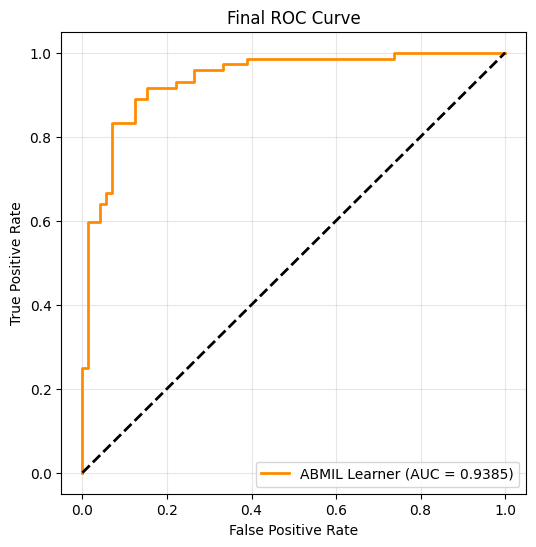

In [ ]:
from sklearn.metrics import roc_curve
if 'test_ds' in locals():
    # Khởi tạo model và tải trọng số tốt nhất đã được lưu trong quá trình train
    model = ABMIL(input_size=FEATS_SIZE, hidden_size=512, output_class=NUM_CLASSES).to(device)
    best_model_path = checkpoints_path / 'abmil_best.pth'

    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        print(f"\nLoaded best model from {best_model_path}")

        # Test evaluation
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
        test_acc, test_auc, test_labels, test_probs = evaluate(model, test_loader)
        test_preds = np.argmax(test_probs, axis=1)

        print(f"\n--- FINAL TEST PERFORMANCE (ABMIL) ---")
        print(f"Accuracy: {test_acc:.4f}")
        print(f"AUC:      {test_auc:.4f}")

        cm = confusion_matrix(test_labels, test_preds)
        print("\nConfusion Matrix:")
        print(cm)

        print(f"\nLUAD (0) - Accuracy: {cm[0,0]/(cm[0,0]+cm[0,1]):.4f}")
        print(f"LUSC (1) - Accuracy: {cm[1,1]/(cm[1,0]+cm[1,1]):.4f}")

        # Vẽ đồ thị đường cong ROC
        fpr, tpr, _ = roc_curve(test_labels, test_probs[:, 1])
        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ABMIL Learner (AUC = {test_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Final ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()

    else:
        print(f"Could not find best model at {best_model_path}")
else:
    print("Test dataset not initialized.")